<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/02_Intraday_Data_Processing_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Intraday Data Processing and EDA

This notebook converts the raw Binance intraday candles from Notebook 01 into the canonical row-level dataset for the new intraday volatility-forecasting experiment.

## Current experiment

- Raw candle interval: **15 minutes**
- Forecast horizon: **next candle**
- Primary target:
  \[
  RV_{t+1}=r_{t+1}^{2}
  \]
  where
  \[
  r_t=\ln(C_t/C_{t-1})
  \]

For 15-minute candles, this is the **next 15-minute squared-return variance proxy**.

## Interval robustness

The code is not hard-coded to 15-minute bar counts.

If the raw-data experiment is later rerun using:

```python
KLINE_INTERVAL = "1h"
```

this notebook automatically converts semantic durations such as:

- 4 hours
- 12 hours
- 24 hours

into the appropriate number of bars.

Example:

| Duration | 15m bars | 1h bars |
|---|---:|---:|
| 4h | 16 | 4 |
| 12h | 48 | 12 |
| 24h | 96 | 24 |

## Leakage policy

For a forecast of candle \(t+1\):

- market features use information through candle \(t\);
- the target is the realized variance of candle \(t+1\);
- target time-of-day and target day-of-week are allowed because the next candle's timestamp is known at forecast time;
- rolling features never use the target candle;
- all return/rolling calculations require consecutive, standard-duration candles.

The 46 historical non-standard Binance close-time rows found in Notebook 01 remain in the raw source, but they are **not treated as valid fixed-horizon returns** in the modeling dataset.

## 1. Imports and Google Drive

In [1]:
from google.colab import drive

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

Mounted at /content/drive


## 2. Configuration

Only `KLINE_INTERVAL` needs to change when switching the upstream raw-data experiment from `15m` to another intraday interval such as `1h`.

Rolling features and future DL lookback candidates are specified as **durations**, not bar counts.

In [2]:
# ============================================================
# USER CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

# Must correspond to an interval already created by Notebook 01.
KLINE_INTERVAL = "15m"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

# Primary rolling variance-state features.
ROLLING_RV_HORIZONS = {
    "rv_mean_4h": "4h",
    "rv_mean_24h": "1d",
}

# Candidate sequence histories for the later DL lookback-selection notebook.
# These are intentionally semantic durations, not fixed row counts.
CANDIDATE_LOOKBACK_DURATIONS = [
    "4h",
    "12h",
    "1d",
]

EPSILON = 1e-12

# Same calendar partitions as the original daily project.
# Splits are assigned using TARGET timestamp.
VALIDATION_START = pd.Timestamp(
    "2024-08-01 00:00:00",
    tz="UTC",
)

TEST_START = pd.Timestamp(
    "2025-08-01 00:00:00",
    tz="UTC",
)

TEST_END_EXCLUSIVE = pd.Timestamp(
    "2026-08-01 00:00:00",
    tz="UTC",
)


# ============================================================
# INTERVAL-SPECIFIC PATHS
# ============================================================

RAW_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / KLINE_INTERVAL
)

MANIFEST_ROOT = (
    PROJECT_ROOT
    / "manifests"
    / KLINE_INTERVAL
)

MODEL_READY_ROOT = (
    PROJECT_ROOT
    / "data"
    / "model_ready"
    / KLINE_INTERVAL
)

ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "artifacts"
    / KLINE_INTERVAL
)

EDA_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "EDA"
)

for directory in [
    MODEL_READY_ROOT,
    ARTIFACT_ROOT,
    EDA_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


FEATURES_PATH = (
    MODEL_READY_ROOT
    / f"crypto_intraday_features_{KLINE_INTERVAL}_v1.parquet"
)

MODEL_ROWS_PATH = (
    MODEL_READY_ROOT
    / f"crypto_intraday_model_rows_{KLINE_INTERVAL}_v1.parquet"
)

SEASONALITY_PATH = (
    ARTIFACT_ROOT
    / f"intraday_seasonality_factors_{KLINE_INTERVAL}.parquet"
)

PROCESSING_MANIFEST_PATH = (
    MANIFEST_ROOT
    / f"processing_manifest_{KLINE_INTERVAL}_v1.json"
)

EDA_SUMMARY_PATH = (
    EDA_ROOT
    / f"train_distribution_summary_{KLINE_INTERVAL}.csv"
)

AUTOCORR_PATH = (
    EDA_ROOT
    / f"train_autocorrelation_summary_{KLINE_INTERVAL}.csv"
)

DOW_PATH = (
    EDA_ROOT
    / f"train_day_of_week_volatility_{KLINE_INTERVAL}.csv"
)

print("Project root:", PROJECT_ROOT)
print("Interval:", KLINE_INTERVAL)
print("Feature output:", FEATURES_PATH)

Project root: /content/drive/MyDrive/Quant Research/15min
Interval: 15m
Feature output: /content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/crypto_intraday_features_15m_v1.parquet


## 3. Load the Notebook 01 manifest and raw parquet

The raw filename is read from the Notebook 01 manifest rather than reconstructed manually.

In [3]:
manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"crypto_binance_{KLINE_INTERVAL}_*_raw_manifest.json"
    )
)

if len(manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one Notebook 01 raw-data manifest "
        f"for {KLINE_INTERVAL}, found {len(manifest_candidates)}:\n"
        + "\n".join(
            str(path)
            for path in manifest_candidates
        )
    )

RAW_MANIFEST_PATH = manifest_candidates[0]

with open(
    RAW_MANIFEST_PATH,
    "r",
    encoding="utf-8",
) as file:
    raw_manifest = json.load(
        file
    )

if (
    raw_manifest[
        "kline_interval"
    ]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Raw manifest interval does not match "
        f"KLINE_INTERVAL={KLINE_INTERVAL}."
    )

INTERVAL_MINUTES = int(
    raw_manifest[
        "interval_minutes"
    ]
)

INTERVAL_MS = int(
    raw_manifest[
        "interval_ms"
    ]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

# This branch is designed for intraday intervals with a regular
# clock-time cycle such as 15m, 30m, 1h, 2h, etc.
if (
    INTERVAL_MINUTES <= 0
    or INTERVAL_MINUTES > 1440
    or 1440 % INTERVAL_MINUTES != 0
):
    raise ValueError(
        "Notebook 02 requires an intraday fixed interval "
        "that evenly divides 24 hours. "
        f"Received {KLINE_INTERVAL} = {INTERVAL_MINUTES} minutes."
    )

BARS_PER_DAY = (
    1440
    // INTERVAL_MINUTES
)

RAW_DATA_PATH = Path(
    raw_manifest[
        "combined_output_path"
    ]
)

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        "Raw parquet from Notebook 01 was not found:\n"
        f"{RAW_DATA_PATH}"
    )

raw_df = pd.read_parquet(
    RAW_DATA_PATH
)

raw_df[
    "open_time"
] = pd.to_datetime(
    raw_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)

raw_df[
    "close_time"
] = pd.to_datetime(
    raw_df[
        "close_time"
    ],
    utc=True,
    errors="raise",
)

raw_df = (
    raw_df.loc[
        raw_df[
            "symbol"
        ].isin(
            SYMBOLS
        )
    ]
    .sort_values(
        [
            "symbol",
            "open_time_ms",
        ]
    )
    .reset_index(drop=True)
)

print("Raw manifest:", RAW_MANIFEST_PATH)
print("Raw parquet:", RAW_DATA_PATH)
print("Interval minutes:", INTERVAL_MINUTES)
print("Bars per day:", BARS_PER_DAY)
print("Raw shape:", raw_df.shape)

Raw manifest: /content/drive/MyDrive/Quant Research/15min/manifests/15m/crypto_binance_15m_btc_eth_sol_xrp_raw_manifest.json
Raw parquet: /content/drive/MyDrive/Quant Research/15min/data/raw/15m/crypto_binance_15m_btc_eth_sol_xrp_raw.parquet
Interval minutes: 15
Bars per day: 96
Raw shape: (1125147, 15)


## 4. Raw-input QC inherited from Notebook 01

In [4]:
required_raw_columns = {
    "symbol",
    "interval",
    "open_time",
    "close_time",
    "open_time_ms",
    "close_time_ms",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
}

missing_raw_columns = (
    required_raw_columns
    - set(
        raw_df.columns
    )
)

if missing_raw_columns:
    raise ValueError(
        "Raw parquet is missing required columns: "
        f"{missing_raw_columns}"
    )

assert not raw_df.duplicated(
    subset=[
        "symbol",
        "open_time_ms",
    ]
).any()

assert (
    raw_df[
        "interval"
    ]
    .eq(
        KLINE_INTERVAL
    )
    .all()
)

assert (
    raw_df[
        "symbol"
    ]
    .nunique()
    == len(
        SYMBOLS
    )
)

assert (
    raw_df[
        [
            "open",
            "high",
            "low",
            "close",
        ]
    ]
    > 0
).all().all()

# Exact fixed-grid candle opens are essential.
assert (
    raw_df[
        "open_time_ms"
    ]
    .mod(
        INTERVAL_MS
    )
    .eq(0)
    .all()
)

raw_input_summary = (
    raw_df
    .groupby("symbol")
    .agg(
        rows=(
            "open_time",
            "size",
        ),
        first_open=(
            "open_time",
            "min",
        ),
        last_open=(
            "open_time",
            "max",
        ),
    )
)

display(
    raw_input_summary
)

print(
    "Raw-input QC passed."
)

,rows,first_open,last_open
symbol,,,
BTCUSDT,313531,2017-08-17 04:00:00+00:00,2026-08-01 23:45:00+00:00
ETHUSDT,313531,2017-08-17 04:00:00+00:00,2026-08-01 23:45:00+00:00
SOLUSDT,209354,2020-08-11 06:00:00+00:00,2026-08-01 23:45:00+00:00
XRPUSDT,288731,2018-05-04 08:00:00+00:00,2026-08-01 23:45:00+00:00


Raw-input QC passed.


## 5. Duration-to-bars helper

Every time-based rolling feature and future sequence lookback is converted from a duration into bars using the actual candle interval.

No downstream notebook should manually assume that:

```text
1 day = 96 rows
```

because that is only true for 15-minute data.

In [5]:
def duration_to_bars(
    duration,
):
    duration_td = pd.Timedelta(
        duration
    )

    if (
        duration_td
        <= pd.Timedelta(0)
    ):
        raise ValueError(
            f"Duration must be positive: {duration}"
        )

    duration_ns = int(
        duration_td.value
    )

    interval_ns = int(
        INTERVAL_DELTA.value
    )

    if (
        duration_ns
        % interval_ns
        != 0
    ):
        raise ValueError(
            f"Duration {duration} is not an exact "
            f"multiple of interval {KLINE_INTERVAL}."
        )

    bars = (
        duration_ns
        // interval_ns
    )

    if bars < 1:
        raise ValueError(
            f"Duration {duration} produced "
            f"invalid bar count {bars}."
        )

    return int(
        bars
    )


ROLLING_RV_BARS = {
    feature_name:
        duration_to_bars(
            duration
        )
    for (
        feature_name,
        duration,
    ) in (
        ROLLING_RV_HORIZONS.items()
    )
}

CANDIDATE_LOOKBACK_BARS = {
    duration:
        duration_to_bars(
            duration
        )
    for duration in (
        CANDIDATE_LOOKBACK_DURATIONS
    )
}

print(
    "Rolling RV bars:",
    ROLLING_RV_BARS,
)

print(
    "Candidate DL lookback bars:",
    CANDIDATE_LOOKBACK_BARS,
)

Rolling RV bars: {'rv_mean_4h': 16, 'rv_mean_24h': 96}
Candidate DL lookback bars: {'4h': 16, '12h': 48, '1d': 96}


## 6. Process each asset with strict fixed-horizon continuity

A return is valid only when:

1. current and previous candle opens are exactly one configured interval apart;
2. both candles have the standard fixed interval duration.

This deliberately excludes the small number of non-standard Binance historical candles from fixed-horizon return construction while preserving them in the raw source file.

In [6]:
def strict_rolling_mean(
    values,
    times,
    bars,
):
    rolling_mean = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .mean()
    )

    rolling_count = (
        values
        .rolling(
            window=bars,
            min_periods=bars,
        )
        .count()
    )

    window_start = (
        times.shift(
            bars - 1
        )
    )

    exact_time_span = (
        (
            times
            - window_start
        )
        == (
            (bars - 1)
            * INTERVAL_DELTA
        )
    )

    valid = (
        rolling_count.eq(
            bars
        )
        & exact_time_span
    )

    return rolling_mean.where(
        valid
    )


processed_frames = []

for symbol in SYMBOLS:

    frame = (
        raw_df.loc[
            raw_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time_ms"
        )
        .reset_index(drop=True)
        .copy()
    )

    frame[
        "expected_close_time_ms"
    ] = (
        frame[
            "open_time_ms"
        ]
        + INTERVAL_MS
        - 1
    )

    frame[
        "standard_duration_candle"
    ] = (
        frame[
            "close_time_ms"
        ]
        .eq(
            frame[
                "expected_close_time_ms"
            ]
        )
    )

    frame[
        "previous_open_time"
    ] = (
        frame[
            "open_time"
        ]
        .shift(1)
    )

    frame[
        "previous_close"
    ] = (
        frame[
            "close"
        ]
        .shift(1)
    )

    frame[
        "previous_standard_duration"
    ] = (
        frame[
            "standard_duration_candle"
        ]
        .shift(1)
        .fillna(False)
        .astype(bool)
    )

    frame[
        "consecutive_from_previous"
    ] = (
        (
            frame[
                "open_time"
            ]
            - frame[
                "previous_open_time"
            ]
        )
        .eq(
            INTERVAL_DELTA
        )
    )

    valid_return = (
        frame[
            "consecutive_from_previous"
        ]
        & frame[
            "standard_duration_candle"
        ]
        & frame[
            "previous_standard_duration"
        ]
    )

    frame[
        "return"
    ] = np.where(
        valid_return,
        np.log(
            frame[
                "close"
            ]
            / frame[
                "previous_close"
            ]
        ),
        np.nan,
    )

    frame[
        "realized_variance"
    ] = (
        frame[
            "return"
        ] ** 2
    )

    frame[
        "log_realized_variance"
    ] = np.where(
        frame[
            "realized_variance"
        ].notna(),
        np.log(
            frame[
                "realized_variance"
            ]
            + EPSILON
        ),
        np.nan,
    )

    frame[
        "absolute_return"
    ] = (
        frame[
            "return"
        ].abs()
    )

    # Scale-free intrabar range.
    frame[
        "high_low_range"
    ] = np.where(
        frame[
            "standard_duration_candle"
        ],
        np.log(
            frame[
                "high"
            ]
            / frame[
                "low"
            ]
        ),
        np.nan,
    )

    frame[
        "log_volume"
    ] = np.where(
        frame[
            "standard_duration_candle"
        ],
        np.log1p(
            frame[
                "volume"
            ]
        ),
        np.nan,
    )

    for (
        feature_name,
        bars,
    ) in (
        ROLLING_RV_BARS.items()
    ):

        frame[
            feature_name
        ] = strict_rolling_mean(
            values=frame[
                "realized_variance"
            ],
            times=frame[
                "open_time"
            ],
            bars=bars,
        )

    # --------------------------------------------------------
    # Next-candle target
    # --------------------------------------------------------

    frame[
        "target_open_time"
    ] = (
        frame[
            "open_time"
        ]
        .shift(-1)
    )

    frame[
        "target_return"
    ] = (
        frame[
            "return"
        ]
        .shift(-1)
    )

    frame[
        "target_realized_variance"
    ] = (
        frame[
            "realized_variance"
        ]
        .shift(-1)
    )

    frame[
        "target_log_realized_variance"
    ] = (
        frame[
            "log_realized_variance"
        ]
        .shift(-1)
    )

    frame[
        "consecutive_to_target"
    ] = (
        (
            frame[
                "target_open_time"
            ]
            - frame[
                "open_time"
            ]
        )
        .eq(
            INTERVAL_DELTA
        )
    )

    invalid_target = (
        ~frame[
            "consecutive_to_target"
        ]
    )

    frame.loc[
        invalid_target,
        [
            "target_return",
            "target_realized_variance",
            "target_log_realized_variance",
        ],
    ] = np.nan

    # --------------------------------------------------------
    # Known-ahead target clock features
    # --------------------------------------------------------

    target_minutes_of_day = (
        frame[
            "target_open_time"
        ].dt.hour
        * 60
        + frame[
            "target_open_time"
        ].dt.minute
    )

    frame[
        "target_slot_index"
    ] = np.where(
        frame[
            "target_open_time"
        ].notna(),
        (
            target_minutes_of_day
            // INTERVAL_MINUTES
        ),
        np.nan,
    )

    time_angle = (
        2
        * np.pi
        * target_minutes_of_day
        / 1440.0
    )

    frame[
        "target_time_sin"
    ] = np.sin(
        time_angle
    )

    frame[
        "target_time_cos"
    ] = np.cos(
        time_angle
    )

    target_day_of_week = (
        frame[
            "target_open_time"
        ].dt.dayofweek
    )

    dow_angle = (
        2
        * np.pi
        * target_day_of_week
        / 7.0
    )

    frame[
        "target_dow_sin"
    ] = np.sin(
        dow_angle
    )

    frame[
        "target_dow_cos"
    ] = np.cos(
        dow_angle
    )

    # --------------------------------------------------------
    # Split by TARGET timestamp
    # --------------------------------------------------------

    frame[
        "split"
    ] = "outside"

    frame.loc[
        frame[
            "target_open_time"
        ].lt(
            VALIDATION_START
        ),
        "split",
    ] = "train"

    frame.loc[
        frame[
            "target_open_time"
        ].ge(
            VALIDATION_START
        )
        & frame[
            "target_open_time"
        ].lt(
            TEST_START
        ),
        "split",
    ] = "validation"

    frame.loc[
        frame[
            "target_open_time"
        ].ge(
            TEST_START
        )
        & frame[
            "target_open_time"
        ].lt(
            TEST_END_EXCLUSIVE
        ),
        "split",
    ] = "test"

    processed_frames.append(
        frame
    )


features_df = (
    pd.concat(
        processed_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "symbol",
            "open_time_ms",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Processed shape:",
    features_df.shape,
)

/tmp/ipykernel_1580/1269977960.py:118: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1580/1269977960.py:118: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1580/1269977960.py:118: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1580/1269977960.py:118: F

Processed shape: (1125147, 40)


## 7. Freeze the canonical DL feature set

The sequence models will later consume these row-level features.

The target-clock terms are safe because the timestamp of the next interval is known before its return is observed.

In [7]:
FEATURE_COLUMNS = [
    "log_realized_variance",
    "return",
    "absolute_return",
    "high_low_range",
    "log_volume",
    *ROLLING_RV_HORIZONS.keys(),
    "target_time_sin",
    "target_time_cos",
    "target_dow_sin",
    "target_dow_cos",
]

TARGET_COLUMN = (
    "target_log_realized_variance"
)

TARGET_VARIANCE_COLUMN = (
    "target_realized_variance"
)

MODEL_REQUIRED_COLUMNS = (
    FEATURE_COLUMNS
    + [
        TARGET_COLUMN,
        TARGET_VARIANCE_COLUMN,
        "target_return",
        "target_open_time",
    ]
)

features_df[
    "valid_model_row"
] = (
    features_df[
        MODEL_REQUIRED_COLUMNS
    ]
    .notna()
    .all(axis=1)
    & features_df[
        "split"
    ]
    .isin(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

print(
    "Feature count:",
    len(
        FEATURE_COLUMNS
    )
)

print(
    "Features:"
)

for feature in (
    FEATURE_COLUMNS
):
    print(
        " -",
        feature,
    )

Feature count: 11
Features:
 - log_realized_variance
 - return
 - absolute_return
 - high_low_range
 - log_volume
 - rv_mean_4h
 - rv_mean_24h
 - target_time_sin
 - target_time_cos
 - target_dow_sin
 - target_dow_cos


## 8. Core target / leakage / continuity QC

In [8]:
# ------------------------------------------------------------
# Return and RV identities
# ------------------------------------------------------------

valid_return_rows = (
    features_df[
        "return"
    ]
    .notna()
)

max_rv_identity_error = float(
    np.nanmax(
        np.abs(
            features_df.loc[
                valid_return_rows,
                "realized_variance",
            ].to_numpy()
            - (
                features_df.loc[
                    valid_return_rows,
                    "return",
                ].to_numpy()
                ** 2
            )
        )
    )
)

assert (
    max_rv_identity_error
    < 1e-18
)


valid_target_rows = (
    features_df[
        TARGET_VARIANCE_COLUMN
    ]
    .notna()
)

max_target_identity_error = float(
    np.nanmax(
        np.abs(
            features_df.loc[
                valid_target_rows,
                TARGET_VARIANCE_COLUMN,
            ].to_numpy()
            - (
                features_df.loc[
                    valid_target_rows,
                    "target_return",
                ].to_numpy()
                ** 2
            )
        )
    )
)

assert (
    max_target_identity_error
    < 1e-18
)


# ------------------------------------------------------------
# Every non-null target must be exactly one interval ahead.
# ------------------------------------------------------------

target_offset = (
    features_df.loc[
        valid_target_rows,
        "target_open_time",
    ]
    - features_df.loc[
        valid_target_rows,
        "open_time",
    ]
)

assert (
    target_offset
    .eq(
        INTERVAL_DELTA
    )
    .all()
)


# ------------------------------------------------------------
# Valid model rows cannot contain feature or target nulls.
# ------------------------------------------------------------

model_rows_df = (
    features_df.loc[
        features_df[
            "valid_model_row"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

assert not (
    model_rows_df[
        MODEL_REQUIRED_COLUMNS
    ]
    .isna()
    .any()
    .any()
)


# ------------------------------------------------------------
# The target must always be strictly in the future.
# ------------------------------------------------------------

assert (
    model_rows_df[
        "target_open_time"
    ]
    > model_rows_df[
        "open_time"
    ]
).all()


# ------------------------------------------------------------
# Non-standard historical candles cannot survive as valid
# current-candle fixed-horizon model rows.
# ------------------------------------------------------------

assert (
    model_rows_df[
        "standard_duration_candle"
    ]
    .all()
)


print(
    "Return identity max error:",
    max_rv_identity_error,
)

print(
    "Target RV identity max error:",
    max_target_identity_error,
)

print(
    "Valid model rows:",
    f"{len(model_rows_df):,}"
)

print(
    "Core target / leakage QC passed."
)

Return identity max error: 0.0
Target RV identity max error: 0.0
Valid model rows: 1,114,295
Core target / leakage QC passed.


## 9. Split counts and coverage

Validation and Test use the same one-year calendar periods as the earlier daily project, but now contain up to `bars_per_day × 365` target observations per asset.

Historical gaps and deliberately excluded non-standard candles can reduce the usable count slightly; they are not filled.

In [9]:
split_summary_df = (
    model_rows_df
    .groupby(
        [
            "symbol",
            "split",
        ]
    )
    .agg(
        observations=(
            "target_open_time",
            "size",
        ),
        first_target=(
            "target_open_time",
            "min",
        ),
        last_target=(
            "target_open_time",
            "max",
        ),
    )
    .reset_index()
)

theoretical_one_year_rows = (
    365
    * BARS_PER_DAY
)

split_summary_df[
    "theoretical_full_year_rows"
] = np.where(
    split_summary_df[
        "split"
    ]
    .isin(
        [
            "validation",
            "test",
        ]
    ),
    theoretical_one_year_rows,
    np.nan,
)

split_summary_df[
    "coverage_pct"
] = np.where(
    split_summary_df[
        "split"
    ]
    .isin(
        [
            "validation",
            "test",
        ]
    ),
    100.0
    * split_summary_df[
        "observations"
    ]
    / theoretical_one_year_rows,
    np.nan,
)

display(
    split_summary_df
)

# Canonical split boundaries must be represented.
for symbol in SYMBOLS:

    validation_rows = (
        model_rows_df.loc[
            model_rows_df[
                "symbol"
            ].eq(symbol)
            & model_rows_df[
                "split"
            ].eq(
                "validation"
            )
        ]
    )

    test_rows = (
        model_rows_df.loc[
            model_rows_df[
                "symbol"
            ].eq(symbol)
            & model_rows_df[
                "split"
            ].eq(
                "test"
            )
        ]
    )

    if (
        validation_rows.empty
        or test_rows.empty
    ):
        raise ValueError(
            f"{symbol}: Validation or Test "
            "contains no valid model rows."
        )

    assert (
        validation_rows[
            "target_open_time"
        ].min()
        >= VALIDATION_START
    )

    assert (
        validation_rows[
            "target_open_time"
        ].max()
        < TEST_START
    )

    assert (
        test_rows[
            "target_open_time"
        ].min()
        >= TEST_START
    )

    assert (
        test_rows[
            "target_open_time"
        ].max()
        < TEST_END_EXCLUSIVE
    )

print(
    "Split coverage QC passed."
)

,symbol,split,observations,first_target,last_target,theoretical_full_year_rows,coverage_pct
0,BTCUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00,35040.0,100.0
1,BTCUSDT,train,239971,2017-08-18 04:15:00+00:00,2024-07-31 23:45:00+00:00,NaN,NaN
2,BTCUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,35040.0,100.0
3,ETHUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00,35040.0,100.0
4,ETHUSDT,train,239971,2017-08-18 04:15:00+00:00,2024-07-31 23:45:00+00:00,NaN,NaN
5,ETHUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,35040.0,100.0
6,SOLUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00,35040.0,100.0
7,SOLUSDT,train,138106,2020-08-12 06:15:00+00:00,2024-07-31 23:45:00+00:00,NaN,NaN
8,SOLUSDT,validation,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00,35040.0,100.0
9,XRPUSDT,test,35040,2025-08-01 00:00:00+00:00,2026-07-31 23:45:00+00:00,35040.0,100.0


Split coverage QC passed.


# Part B — Training-only EDA

All diagnostic distributions and seasonality estimates below use the **training period only**.

Validation and Test remain reserved for later model comparison.

## 10. Training return / variance distribution summary

In [10]:
train_eda_df = (
    features_df.loc[
        features_df[
            "open_time"
        ].lt(
            VALIDATION_START
        )
        & features_df[
            "return"
        ].notna()
    ]
    .copy()
)

summary_rows = []

for symbol in SYMBOLS:

    current = (
        train_eda_df.loc[
            train_eda_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    returns = (
        current[
            "return"
        ]
        .to_numpy(
            dtype=float
        )
    )

    rv = (
        current[
            "realized_variance"
        ]
        .to_numpy(
            dtype=float
        )
    )

    summary_rows.append({
        "symbol":
            symbol,

        "observations":
            len(
                current
            ),

        "return_mean":
            float(
                np.mean(
                    returns
                )
            ),

        "return_std":
            float(
                np.std(
                    returns,
                    ddof=1,
                )
            ),

        "return_skew":
            float(
                current[
                    "return"
                ].skew()
            ),

        "return_excess_kurtosis":
            float(
                current[
                    "return"
                ].kurt()
            ),

        "zero_return_pct":
            float(
                100.0
                * np.mean(
                    returns
                    == 0
                )
            ),

        "rv_median":
            float(
                np.median(
                    rv
                )
            ),

        "rv_p95":
            float(
                np.quantile(
                    rv,
                    0.95,
                )
            ),

        "rv_p99":
            float(
                np.quantile(
                    rv,
                    0.99,
                )
            ),

        "rv_p999":
            float(
                np.quantile(
                    rv,
                    0.999,
                )
            ),
    })


train_distribution_df = (
    pd.DataFrame(
        summary_rows
    )
)

display(
    train_distribution_df.style.format({
        "return_mean":
            "{:.8f}",
        "return_std":
            "{:.8f}",
        "return_skew":
            "{:.3f}",
        "return_excess_kurtosis":
            "{:.3f}",
        "zero_return_pct":
            "{:.4f}",
        "rv_median":
            "{:.10f}",
        "rv_p95":
            "{:.10f}",
        "rv_p99":
            "{:.10f}",
        "rv_p999":
            "{:.10f}",
    })
)

train_distribution_df.to_csv(
    EDA_SUMMARY_PATH,
    index=False,
)

,symbol,observations,return_mean,return_std,return_skew,return_excess_kurtosis,zero_return_pct,rv_median,rv_p95,rv_p99,rv_p999
0,BTCUSDT,243304,0.00001086,0.00428574,-0.003,66.200,0.1550,0.0000020081,0.0000650661,0.0002657423,0.0013298225
1,ETHUSDT,243304,0.00000934,0.00518550,-0.096,50.484,0.5598,0.0000033334,0.0000967434,0.0003777111,0.0017842568
2,SOLUSDT,139162,0.00002770,0.00752761,0.343,29.548,2.5050,0.0000089373,0.0002121213,0.0007772042,0.0030469519
3,XRPUSDT,218519,-0.00000215,0.00583104,-1.614,138.761,1.8012,0.0000037125,0.0001054002,0.0004626263,0.0026679119


## 11. Training-only intraday seasonality factors

For each asset and clock-time slot, estimate:

\[
S_{a,s}
=
rac{
E[RV_t \mid asset=a, slot=s, Train]
}{
E[RV_t \mid asset=a, Train]
}
\]

This is a **variance factor**.

Its square root is the corresponding volatility factor.

These factors are saved for use by the later intraday ARCH notebook, where they can be used to deseasonalize returns without learning seasonality from Validation or Test.

In [11]:
seasonality_frames = []

for symbol in SYMBOLS:

    current = (
        train_eda_df.loc[
            train_eda_df[
                "symbol"
            ].eq(symbol)
        ]
        .copy()
    )

    current_minutes = (
        current[
            "open_time"
        ].dt.hour
        * 60
        + current[
            "open_time"
        ].dt.minute
    )

    current[
        "slot_index"
    ] = (
        current_minutes
        // INTERVAL_MINUTES
    ).astype(int)

    overall_mean_rv = float(
        current[
            "realized_variance"
        ].mean()
    )

    if (
        not np.isfinite(
            overall_mean_rv
        )
        or overall_mean_rv
        <= 0
    ):
        raise ValueError(
            f"{symbol}: invalid Train mean RV."
        )

    slot_df = (
        current
        .groupby(
            "slot_index"
        )
        .agg(
            observations=(
                "realized_variance",
                "size",
            ),
            mean_rv=(
                "realized_variance",
                "mean",
            ),
            median_rv=(
                "realized_variance",
                "median",
            ),
        )
        .reset_index()
    )

    expected_slots = set(
        range(
            BARS_PER_DAY
        )
    )

    actual_slots = set(
        slot_df[
            "slot_index"
        ]
        .astype(int)
        .tolist()
    )

    if (
        actual_slots
        != expected_slots
    ):
        raise ValueError(
            f"{symbol}: missing Train time-of-day slots. "
            f"Missing={sorted(expected_slots - actual_slots)}"
        )

    slot_df[
        "symbol"
    ] = symbol

    slot_df[
        "interval"
    ] = KLINE_INTERVAL

    slot_df[
        "slot_start_hour_utc"
    ] = (
        slot_df[
            "slot_index"
        ]
        * INTERVAL_MINUTES
        / 60.0
    )

    slot_df[
        "overall_train_mean_rv"
    ] = overall_mean_rv

    slot_df[
        "variance_seasonality_factor"
    ] = (
        slot_df[
            "mean_rv"
        ]
        / overall_mean_rv
    )

    slot_df[
        "volatility_seasonality_factor"
    ] = np.sqrt(
        slot_df[
            "variance_seasonality_factor"
        ]
    )

    seasonality_frames.append(
        slot_df
    )


seasonality_df = (
    pd.concat(
        seasonality_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "symbol",
            "slot_index",
        ]
    )
    .reset_index(drop=True)
)

assert (
    seasonality_df[
        "variance_seasonality_factor"
    ]
    > 0
).all()

seasonality_df.to_parquet(
    SEASONALITY_PATH,
    index=False,
)

display(
    seasonality_df.head(
        min(
            20,
            len(
                seasonality_df
            ),
        )
    )
)

print(
    "Saved training-only seasonality factors:",
    SEASONALITY_PATH,
)

,slot_index,observations,mean_rv,median_rv,symbol,interval,slot_start_hour_utc,overall_train_mean_rv,variance_seasonality_factor,volatility_seasonality_factor
0,0,2539,0.000025,0.000004,BTCUSDT,15m,0.00,0.000018,1.372198,1.171409
1,1,2537,0.000025,0.000003,BTCUSDT,15m,0.25,0.000018,1.380978,1.175150
2,2,2537,0.000019,0.000003,BTCUSDT,15m,0.50,0.000018,1.043934,1.021731
3,3,2537,0.000016,0.000002,BTCUSDT,15m,0.75,0.000018,0.847768,0.920743
4,4,2537,0.000018,0.000003,BTCUSDT,15m,1.00,0.000018,0.986694,0.993325
5,5,2537,0.000016,0.000002,BTCUSDT,15m,1.25,0.000018,0.890107,0.943455
6,6,2537,0.000018,0.000002,BTCUSDT,15m,1.50,0.000018,0.968806,0.984280
7,7,2536,0.000019,0.000002,BTCUSDT,15m,1.75,0.000018,1.035301,1.017498
8,8,2524,0.000020,0.000002,BTCUSDT,15m,2.00,0.000018,1.100997,1.049284
9,9,2524,0.000018,0.000002,BTCUSDT,15m,2.25,0.000018,0.964531,0.982105


Saved training-only seasonality factors: /content/drive/MyDrive/Quant Research/15min/artifacts/15m/intraday_seasonality_factors_15m.parquet


## 12. Intraday seasonality plots

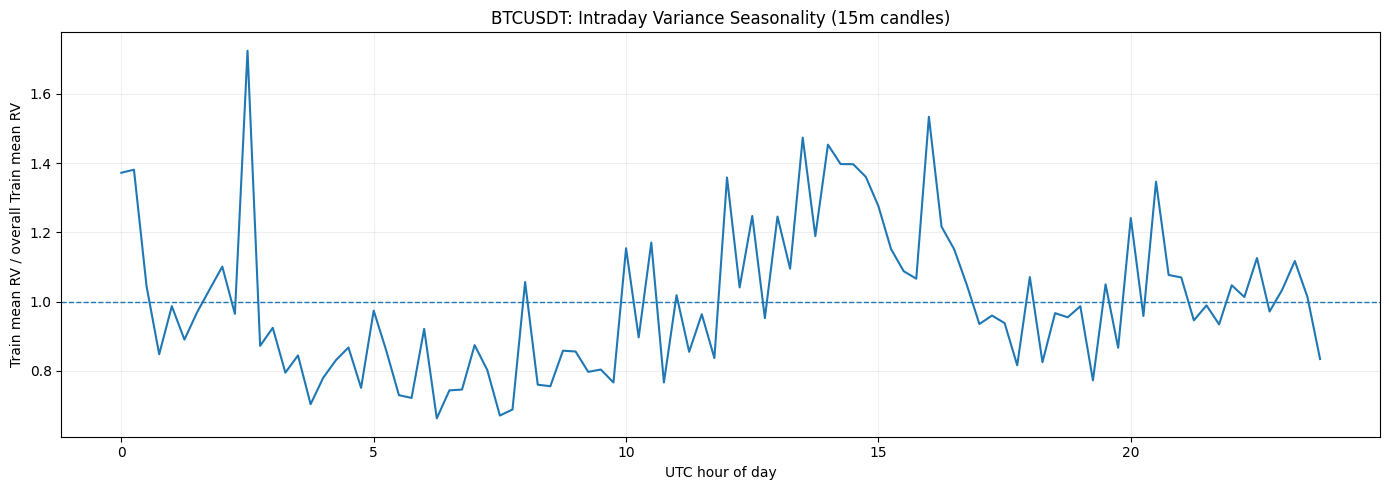

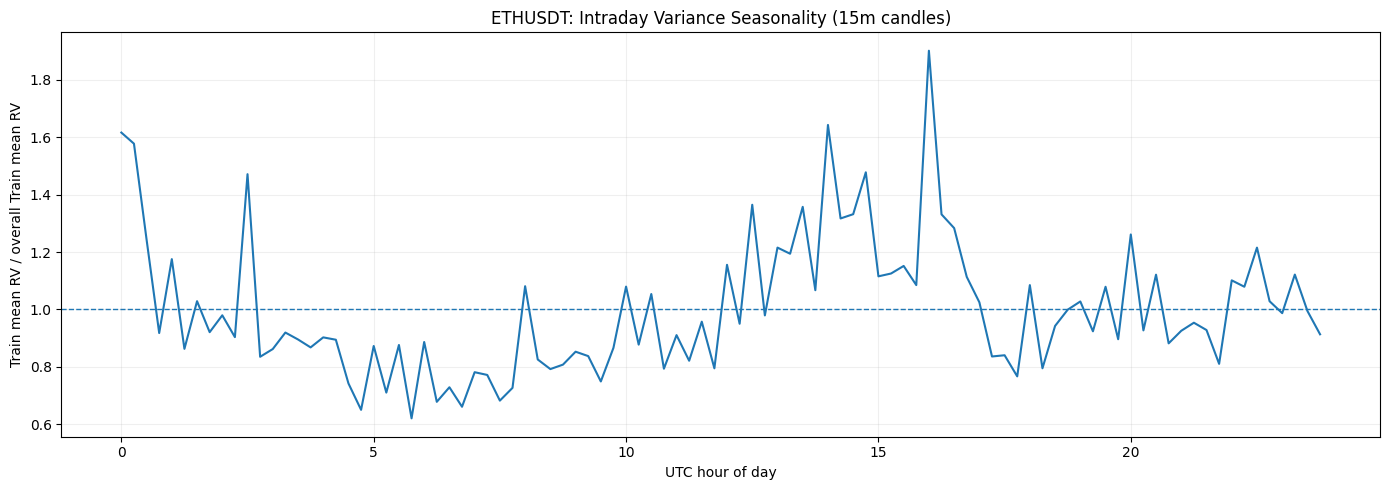

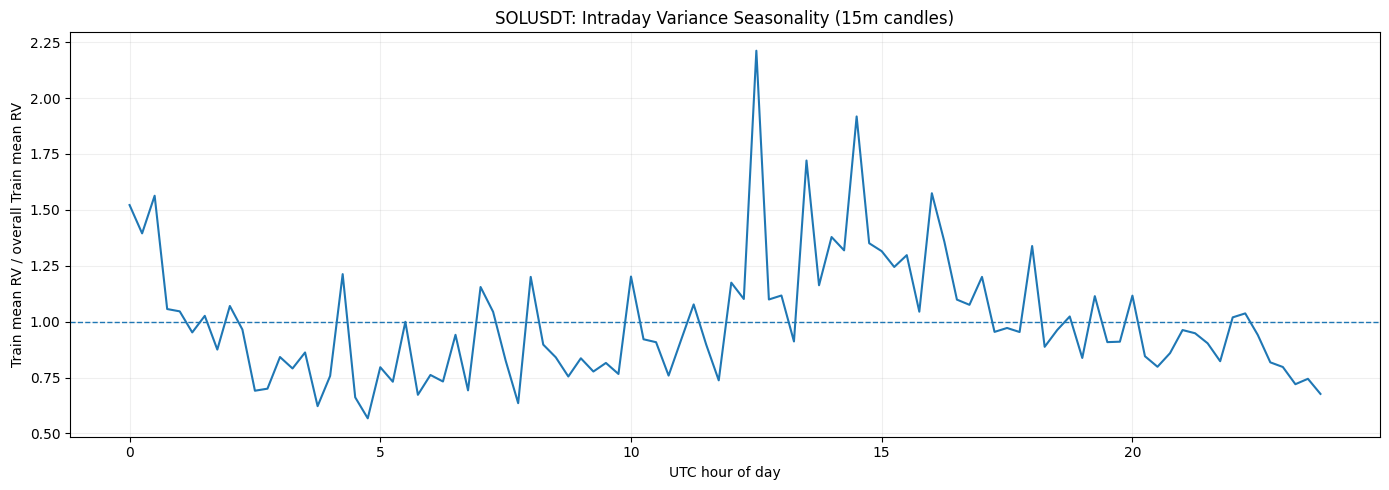

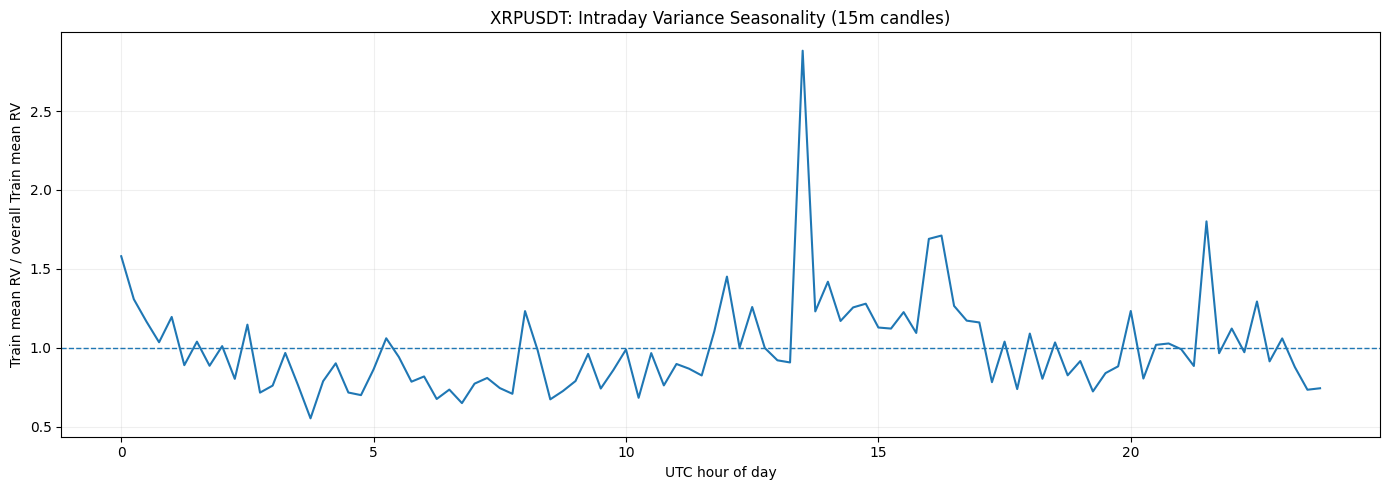

In [12]:
for symbol in SYMBOLS:

    current = (
        seasonality_df.loc[
            seasonality_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "slot_index"
        )
    )

    plt.figure(
        figsize=(
            14,
            5,
        )
    )

    plt.plot(
        current[
            "slot_start_hour_utc"
        ],
        current[
            "variance_seasonality_factor"
        ],
    )

    plt.axhline(
        1.0,
        linewidth=1,
        linestyle="--",
    )

    plt.xlabel(
        "UTC hour of day"
    )

    plt.ylabel(
        "Train mean RV / overall Train mean RV"
    )

    plt.title(
        f"{symbol}: Intraday Variance Seasonality "
        f"({KLINE_INTERVAL} candles)"
    )

    plt.grid(
        alpha=0.20
    )

    plt.tight_layout()

    plot_path = (
        EDA_ROOT
        / (
            f"{symbol}_intraday_variance_"
            f"seasonality_{KLINE_INTERVAL}.png"
        )
    )

    plt.savefig(
        plot_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

## 13. Day-of-week volatility pattern

In [13]:
dow_rows = []

for symbol in SYMBOLS:

    current = (
        train_eda_df.loc[
            train_eda_df[
                "symbol"
            ].eq(symbol)
        ]
        .copy()
    )

    current[
        "day_of_week"
    ] = (
        current[
            "open_time"
        ].dt.dayofweek
    )

    overall_mean_rv = float(
        current[
            "realized_variance"
        ].mean()
    )

    grouped = (
        current
        .groupby(
            "day_of_week"
        )
        .agg(
            observations=(
                "realized_variance",
                "size",
            ),
            mean_rv=(
                "realized_variance",
                "mean",
            ),
        )
        .reset_index()
    )

    grouped[
        "symbol"
    ] = symbol

    grouped[
        "normalized_mean_rv"
    ] = (
        grouped[
            "mean_rv"
        ]
        / overall_mean_rv
    )

    dow_rows.append(
        grouped
    )


dow_df = (
    pd.concat(
        dow_rows,
        ignore_index=True,
    )
)

dow_name_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

dow_df[
    "day_name"
] = (
    dow_df[
        "day_of_week"
    ]
    .map(
        dow_name_map
    )
)

display(
    dow_df[
        [
            "symbol",
            "day_of_week",
            "day_name",
            "observations",
            "mean_rv",
            "normalized_mean_rv",
        ]
    ]
)

dow_df.to_csv(
    DOW_PATH,
    index=False,
)

,symbol,day_of_week,day_name,observations,mean_rv,normalized_mean_rv
0,BTCUSDT,0,Mon,34806,0.000018,0.979165
1,BTCUSDT,1,Tue,34771,0.000019,1.049327
2,BTCUSDT,2,Wed,34655,0.000021,1.141917
3,BTCUSDT,3,Thu,34687,0.000020,1.107193
4,BTCUSDT,4,Fri,34752,0.000023,1.232753
5,BTCUSDT,5,Sat,34828,0.000013,0.700529
6,BTCUSDT,6,Sun,34805,0.000015,0.790692
7,ETHUSDT,0,Mon,34806,0.000028,1.025964
8,ETHUSDT,1,Tue,34771,0.000030,1.118500
9,ETHUSDT,2,Wed,34655,0.000031,1.142383


## 14. Training autocorrelation summary

Instead of hard-coding lags in rows, diagnostic lags are defined in elapsed time and converted to bars.

The default checks:

- one candle;
- 1 hour;
- 4 hours;
- 24 hours.

Duplicate bar lags are automatically removed. For example, on 1-hour data the "one candle" and "1 hour" lag are the same.

In [14]:
diagnostic_lag_durations = {
    "one_candle":
        INTERVAL_DELTA,

    "1h":
        pd.Timedelta(
            hours=1
        ),

    "4h":
        pd.Timedelta(
            hours=4
        ),

    "24h":
        pd.Timedelta(
            days=1
        ),
}


lag_bar_map = {}

for (
    label,
    duration,
) in (
    diagnostic_lag_durations.items()
):

    if (
        duration
        < INTERVAL_DELTA
    ):
        continue

    duration_ns = int(
        duration.value
    )

    interval_ns = int(
        INTERVAL_DELTA.value
    )

    if (
        duration_ns
        % interval_ns
        != 0
    ):
        continue

    lag_bars = int(
        duration_ns
        // interval_ns
    )

    lag_bar_map[
        label
    ] = lag_bars


autocorr_rows = []

for symbol in SYMBOLS:

    current = (
        train_eda_df.loc[
            train_eda_df[
                "symbol"
            ].eq(symbol)
        ]
        .sort_values(
            "open_time"
        )
    )

    return_series = (
        current[
            "return"
        ]
    )

    rv_series = (
        current[
            "realized_variance"
        ]
    )

    seen_lags = set()

    for (
        label,
        lag_bars,
    ) in (
        lag_bar_map.items()
    ):

        if (
            lag_bars
            in seen_lags
        ):
            continue

        seen_lags.add(
            lag_bars
        )

        autocorr_rows.append({
            "symbol":
                symbol,

            "lag_label":
                label,

            "lag_bars":
                lag_bars,

            "return_autocorrelation":
                float(
                    return_series.autocorr(
                        lag=lag_bars
                    )
                ),

            "rv_autocorrelation":
                float(
                    rv_series.autocorr(
                        lag=lag_bars
                    )
                ),
        })


autocorr_df = (
    pd.DataFrame(
        autocorr_rows
    )
)

display(
    autocorr_df.style.format({
        "return_autocorrelation":
            "{:.6f}",
        "rv_autocorrelation":
            "{:.6f}",
    })
)

autocorr_df.to_csv(
    AUTOCORR_PATH,
    index=False,
)

,symbol,lag_label,lag_bars,return_autocorrelation,rv_autocorrelation
0,BTCUSDT,one_candle,1,-0.018360,0.287626
1,BTCUSDT,1h,4,-0.014484,0.147204
2,BTCUSDT,4h,16,0.000660,0.068386
3,BTCUSDT,24h,96,-0.016539,0.040643
4,ETHUSDT,one_candle,1,-0.004999,0.291458
5,ETHUSDT,1h,4,-0.010379,0.171255
6,ETHUSDT,4h,16,-0.002723,0.079442
7,ETHUSDT,24h,96,-0.019241,0.046515
8,SOLUSDT,one_candle,1,0.001284,0.199672
9,SOLUSDT,1h,4,-0.009418,0.165683


# Part C — Save canonical processed datasets

## 15. Select stable output columns

In [15]:
OUTPUT_COLUMNS = [
    "symbol",
    "interval",
    "open_time",
    "close_time",
    "open_time_ms",
    "close_time_ms",
    "close",
    "volume",
    "standard_duration_candle",
    "consecutive_from_previous",
    "return",
    "realized_variance",
    "log_realized_variance",
    "absolute_return",
    "high_low_range",
    "log_volume",
    *ROLLING_RV_HORIZONS.keys(),
    "target_open_time",
    "target_return",
    "target_realized_variance",
    "target_log_realized_variance",
    "consecutive_to_target",
    "target_slot_index",
    "target_time_sin",
    "target_time_cos",
    "target_dow_sin",
    "target_dow_cos",
    "split",
    "valid_model_row",
]

features_output_df = (
    features_df[
        OUTPUT_COLUMNS
    ]
    .copy()
)

model_rows_output_df = (
    model_rows_df[
        OUTPUT_COLUMNS
    ]
    .copy()
)

print(
    "Full feature dataset:",
    features_output_df.shape,
)

print(
    "Valid row-level model dataset:",
    model_rows_output_df.shape,
)

Full feature dataset: (1125147, 30)
Valid row-level model dataset: (1114295, 30)


## 16. Save parquet files and reload them

In [16]:
features_output_df.to_parquet(
    FEATURES_PATH,
    index=False,
)

model_rows_output_df.to_parquet(
    MODEL_ROWS_PATH,
    index=False,
)

reloaded_features = pd.read_parquet(
    FEATURES_PATH
)

reloaded_model_rows = pd.read_parquet(
    MODEL_ROWS_PATH
)

assert (
    len(
        reloaded_features
    )
    == len(
        features_output_df
    )
)

assert (
    len(
        reloaded_model_rows
    )
    == len(
        model_rows_output_df
    )
)

assert list(
    reloaded_features.columns
) == OUTPUT_COLUMNS

assert list(
    reloaded_model_rows.columns
) == OUTPUT_COLUMNS

assert not (
    reloaded_model_rows[
        MODEL_REQUIRED_COLUMNS
    ]
    .isna()
    .any()
    .any()
)

print(
    "Saved and reloaded:"
)

print(
    " -",
    FEATURES_PATH,
)

print(
    " -",
    MODEL_ROWS_PATH,
)

print(
    "Persistence QC passed."
)

Saved and reloaded:
 - /content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/crypto_intraday_features_15m_v1.parquet
 - /content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/crypto_intraday_model_rows_15m_v1.parquet
Persistence QC passed.


## 17. Create processing manifest

In [17]:
def sha256_file(
    path,
    chunk_size=1024 * 1024,
):
    digest = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    return digest.hexdigest()


split_manifest = {}

for (
    symbol,
    split,
), current in (
    model_rows_output_df
    .groupby(
        [
            "symbol",
            "split",
        ]
    )
):

    split_manifest[
        f"{symbol}_{split}"
    ] = {
        "observations":
            int(
                len(
                    current
                )
            ),

        "first_target_utc":
            current[
                "target_open_time"
            ]
            .min()
            .isoformat(),

        "last_target_utc":
            current[
                "target_open_time"
            ]
            .max()
            .isoformat(),
    }


processing_manifest = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "project_stage":
        "02_intraday_processing_and_eda",

    "source_raw_manifest":
        str(
            RAW_MANIFEST_PATH
        ),

    "source_raw_parquet":
        str(
            RAW_DATA_PATH
        ),

    "kline_interval":
        KLINE_INTERVAL,

    "interval_minutes":
        INTERVAL_MINUTES,

    "interval_ms":
        INTERVAL_MS,

    "bars_per_day":
        BARS_PER_DAY,

    "return_definition":
        "log(close_t / close_t_minus_1)",

    "variance_definition":
        "squared_next_candle_log_return",

    "forecast_horizon":
        "one_candle_ahead",

    "target_column":
        TARGET_COLUMN,

    "target_variance_column":
        TARGET_VARIANCE_COLUMN,

    "epsilon":
        EPSILON,

    "feature_columns":
        FEATURE_COLUMNS,

    "rolling_rv_horizons":
        ROLLING_RV_HORIZONS,

    "rolling_rv_bars":
        ROLLING_RV_BARS,

    "candidate_lookback_durations":
        CANDIDATE_LOOKBACK_DURATIONS,

    "candidate_lookback_bars":
        CANDIDATE_LOOKBACK_BARS,

    "split_boundaries_utc": {
        "train_target_before":
            VALIDATION_START.isoformat(),

        "validation_target_start":
            VALIDATION_START.isoformat(),

        "validation_target_end_exclusive":
            TEST_START.isoformat(),

        "test_target_start":
            TEST_START.isoformat(),

        "test_target_end_exclusive":
            TEST_END_EXCLUSIVE.isoformat(),
    },

    "continuity_policy": {
        "return_requires_exact_previous_open_gap":
            str(
                INTERVAL_DELTA
            ),

        "target_requires_exact_next_open_gap":
            str(
                INTERVAL_DELTA
            ),

        "non_standard_duration_candles_used_for_fixed_horizon_returns":
            False,

        "fill_missing_candles":
            False,
    },

    "time_features": {
        "target_time_of_day_known_ahead":
            True,

        "target_day_of_week_known_ahead":
            True,

        "time_encoding":
            "cyclical_sin_cos",
    },

    "seasonality_factor_estimation":
        "per_asset_train_only_mean_rv_by_utc_slot_divided_by_overall_train_mean_rv",

    "outputs": {
        "full_features_parquet":
            str(
                FEATURES_PATH
            ),

        "valid_model_rows_parquet":
            str(
                MODEL_ROWS_PATH
            ),

        "seasonality_factors_parquet":
            str(
                SEASONALITY_PATH
            ),
    },

    "output_sha256": {
        "full_features":
            sha256_file(
                FEATURES_PATH
            ),

        "valid_model_rows":
            sha256_file(
                MODEL_ROWS_PATH
            ),

        "seasonality_factors":
            sha256_file(
                SEASONALITY_PATH
            ),
    },

    "split_summary":
        split_manifest,
}


with open(
    PROCESSING_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        processing_manifest,
        file,
        indent=2,
        ensure_ascii=False,
    )


print(
    "Saved processing manifest:"
)

print(
    PROCESSING_MANIFEST_PATH
)

Saved processing manifest:
/content/drive/MyDrive/Quant Research/15min/manifests/15m/processing_manifest_15m_v1.json


## 18. Final end-to-end QC

In [18]:
assert FEATURES_PATH.exists()
assert MODEL_ROWS_PATH.exists()
assert SEASONALITY_PATH.exists()
assert PROCESSING_MANIFEST_PATH.exists()

assert (
    model_rows_output_df[
        "split"
    ]
    .isin(
        [
            "train",
            "validation",
            "test",
        ]
    )
    .all()
)

assert (
    model_rows_output_df[
        "target_open_time"
    ]
    .sub(
        model_rows_output_df[
            "open_time"
        ]
    )
    .eq(
        INTERVAL_DELTA
    )
    .all()
)

assert (
    model_rows_output_df[
        "consecutive_to_target"
    ]
    .all()
)

assert (
    model_rows_output_df[
        "standard_duration_candle"
    ]
    .all()
)

assert (
    seasonality_df[
        "symbol"
    ]
    .nunique()
    == len(
        SYMBOLS
    )
)

assert (
    seasonality_df
    .groupby(
        "symbol"
    )[
        "slot_index"
    ]
    .nunique()
    .eq(
        BARS_PER_DAY
    )
    .all()
)

assert (
    len(
        FEATURE_COLUMNS
    )
    == len(
        set(
            FEATURE_COLUMNS
        )
    )
)

print(
    "ALL INTRADAY PROCESSING / EDA "
    "QC CHECKS PASSED."
)

print(
    "\nFrozen forecast target:"
)

print(
    f"next {KLINE_INTERVAL} candle squared log return"
)

print(
    "\nCandidate DL lookbacks:"
)

for (
    duration,
    bars,
) in (
    CANDIDATE_LOOKBACK_BARS.items()
):

    print(
        f" - {duration}: "
        f"{bars} bars"
    )

print(
    "\nNext notebook:"
)

print(
    "03_Intraday_Baselines_and_ARCH.ipynb"
)

ALL INTRADAY PROCESSING / EDA QC CHECKS PASSED.

Frozen forecast target:
next 15m candle squared log return

Candidate DL lookbacks:
 - 4h: 16 bars
 - 12h: 48 bars
 - 1d: 96 bars

Next notebook:
03_Intraday_Baselines_and_ARCH.ipynb


# Methodology frozen by Notebook 02

After this notebook is accepted, the core intraday setup is:

### Forecast target

\[
RV_{t+1}=r_{t+1}^{2}
\]

where \(r_{t+1}\) is the next candle's close-to-close log return.

### Row-level DL features

- current log variance proxy;
- current return;
- absolute return;
- scale-free high/low range;
- log volume;
- trailing 4-hour mean RV;
- trailing 24-hour mean RV;
- known-ahead target time-of-day sine/cosine;
- known-ahead target day-of-week sine/cosine.

### Candidate DL sequence histories

- 4 hours;
- 12 hours;
- 24 hours.

The bar count associated with each duration is inferred from the candle interval. This means the same methodology remains usable if the raw experiment is later changed from 15-minute candles to 1-hour candles.

### Intraday seasonality

A per-asset, training-only clock-slot variance factor is saved for later ARCH deseasonalization.

### Data gaps / unusual historical candles

They are not imputed. Returns, rolling features, targets and future sequences are required to respect exact fixed-interval continuity.